##### Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

##### Load Test Data

In [15]:
test_df = pd.read_csv("../data/processed/test.csv")

In [16]:
test_df.shape

(15200, 171)

In [17]:
test_df.head()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000,class
0,-0.101763,-6.672382e-17,2.293749,-0.005367,-0.042858,-0.053164,-1.010922e-02,-0.022717,-5.585031e-02,-0.111006,...,-0.209908,-2.380616e-01,-2.505123e-01,-0.209612,-0.146392,6.058065e-01,1.232924,-0.021052,-0.021654,0
1,-0.213510,-6.672382e-17,-0.461639,-0.005406,-0.042858,-0.053164,-1.137989e-02,-0.022936,-5.591883e-02,-0.111097,...,-0.382841,-3.727268e-01,-3.472398e-01,-0.306253,-0.201108,-2.940930e-01,-0.169739,-0.021052,-0.021654,0
2,-0.209098,-4.370160e-01,2.293749,-0.005405,-0.042858,-0.053164,-1.137989e-02,-0.022936,-5.591883e-02,-0.111097,...,-0.378423,-3.652879e-01,-3.340260e-01,-0.290212,-0.197353,-2.930830e-01,-0.169053,-0.021052,-0.021654,0
3,0.748620,-4.370160e-01,-0.461639,-0.005406,1.516210,4.596903,-1.389017e-18,0.000000,-1.038652e-17,0.000000,...,0.000000,-4.813233e-17,5.066850e-17,0.000000,0.000000,-6.123344e-17,0.000000,-0.021052,-0.021654,0
4,-0.196079,-6.672382e-17,2.293749,-0.005404,-0.042858,-0.053164,-1.137989e-02,-0.022936,-5.591883e-02,-0.111097,...,-0.342113,-3.349718e-01,-3.180161e-01,-0.282347,-0.186412,-2.447634e-01,-0.140365,-0.021052,-0.021654,0


##### Separate Features and Target

In [18]:
x_test=test_df.drop(columns=["class"])
y_test=test_df["class"]

In [19]:
x_test.shape,y_test.shape

((15200, 170), (15200,))

##### Load All Models

In [20]:
with open("../artifacts/logistic_regression.pkl", "rb") as file:
    logistic_model = pickle.load(file)

In [21]:
with open("../artifacts/knn.pkl", "rb") as file:
    knn_model = pickle.load(file)

In [22]:
with open("../artifacts/decision_tree.pkl", "rb") as file:
    decision_tree_model = pickle.load(file)

In [23]:
with open("../artifacts/random_forest.pkl", "rb") as file:
    random_forest_model = pickle.load(file)

In [24]:
with open("../artifacts/svm.pkl", "rb") as file:
    svm_model = pickle.load(file)

In [25]:
with open("../artifacts/naive_bayes.pkl", "rb") as file:
    naive_bayes_model = pickle.load(file)

In [26]:
with open("../artifacts/gradient_boosting.pkl", "rb") as file:
    gradient_boosting_model = pickle.load(file)

In [27]:
with open("../artifacts/adaboost.pkl", "rb") as file:
    adaboost_model = pickle.load(file)

In [28]:
with open("../artifacts/xgboost.pkl", "rb") as file:
    xgboost_model = pickle.load(file)

## Logistic Regression Evaluation

In [29]:
logistic_predictions = logistic_model.predict(x_test)

##### Accuracy

In [30]:
logistic_accuracy = accuracy_score(y_test,logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9745394736842106


##### Precision

In [31]:
logistic_precision = precision_score(y_test, logistic_predictions)

print("Logistic Regression Precision:", logistic_precision)

Logistic Regression Precision: 0.4081967213114754


##### Recall

In [32]:
logistic_recall = recall_score(y_test,logistic_predictions)

print("Logistic Regression Recall:", logistic_recall)

Logistic Regression Recall: 0.9054545454545454


##### F1 Score

In [33]:
logistic_f1 = f1_score(y_test,logistic_predictions)

print("Logistic Regression F1 Score:", logistic_f1)

Logistic Regression F1 Score: 0.5627118644067797


##### Classification Report

In [34]:
print( classification_report(y_test,logistic_predictions ))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14925
           1       0.41      0.91      0.56       275

    accuracy                           0.97     15200
   macro avg       0.70      0.94      0.77     15200
weighted avg       0.99      0.97      0.98     15200



##### Confusion Matrix

In [35]:
logistic_cm = confusion_matrix(y_test,logistic_predictions)

print(logistic_cm)

[[14564   361]
 [   26   249]]


##### Confusion Matrix Display

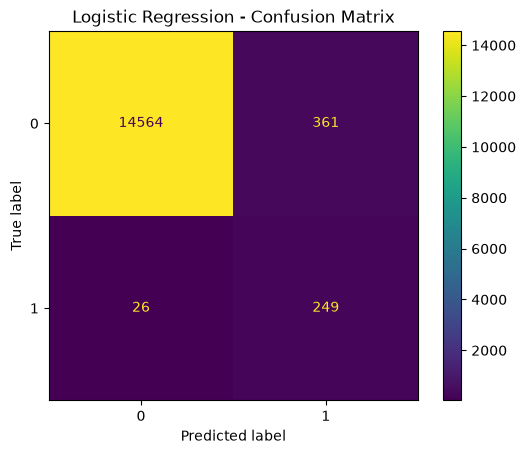

In [36]:
cm = confusion_matrix(y_test, logistic_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

##### ROC Curve

In [37]:
logistic_probability = logistic_model.predict_proba(x_test)[:, 1]

In [38]:
logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(y_test,logistic_probability)

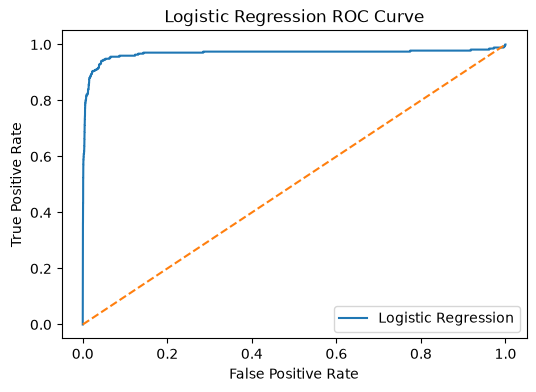

In [39]:
plt.figure(figsize=(6, 4))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [40]:
logistic_roc_auc = roc_auc_score( y_test,logistic_probability)

print("Logistic Regression ROC-AUC:", logistic_roc_auc)

Logistic Regression ROC-AUC: 0.9682142835389066


## KNN Evaluation

In [41]:
knn_predictions = knn_model.predict(x_test)

##### Accuracy

In [42]:
knn_accuracy = accuracy_score(y_test,knn_predictions)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9775


##### Precision

In [43]:
knn_precision = precision_score(y_test,knn_predictions)

print("KNN Precision:", knn_precision)

KNN Precision: 0.44173913043478263


##### Recall

In [44]:
knn_recall = recall_score(y_test,knn_predictions)

print("KNN Recall:", knn_recall)

KNN Recall: 0.9236363636363636


##### F1 Score

In [45]:
knn_f1 = f1_score(y_test,knn_predictions)

print("KNN F1 Score:", knn_f1)

KNN F1 Score: 0.5976470588235294


##### Classification Report

In [46]:
print(classification_report(y_test,knn_predictions))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14925
           1       0.44      0.92      0.60       275

    accuracy                           0.98     15200
   macro avg       0.72      0.95      0.79     15200
weighted avg       0.99      0.98      0.98     15200



##### Confusion Matrix

In [47]:
knn_cm = confusion_matrix(y_test,knn_predictions)

print(knn_cm)

[[14604   321]
 [   21   254]]


##### Confusion Matrix Display

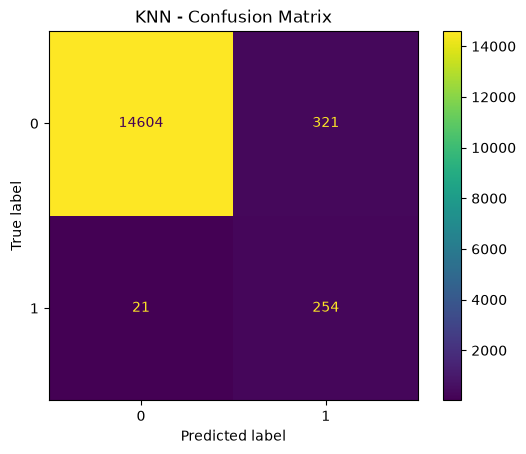

In [48]:
cm = confusion_matrix(y_test, knn_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("KNN - Confusion Matrix")

plt.show()

##### ROC Curve

In [49]:
knn_probability = knn_model.predict_proba(x_test)[:, 1]

In [50]:
knn_fpr, knn_tpr, knn_thresholds = roc_curve( y_test,knn_probability)

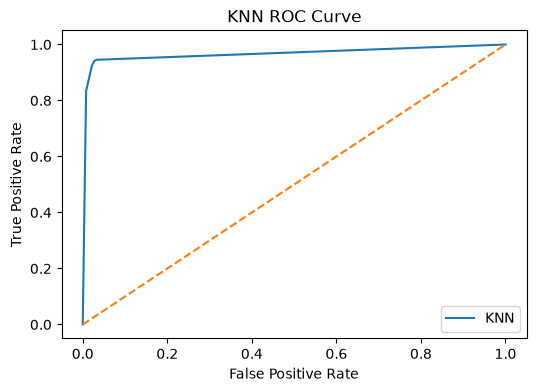

In [51]:
plt.figure(figsize=(6, 4))

plt.plot(
    knn_fpr,
    knn_tpr,
    label="KNN"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("KNN ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [52]:
knn_roc_auc = roc_auc_score(y_test,knn_probability)

print("KNN ROC-AUC:", knn_roc_auc)

KNN ROC-AUC: 0.9666268311253235


## Decision Tree Evaluation

In [53]:
decision_tree_predictions=decision_tree_model.predict(x_test)

##### Accuracy

In [ ]:
decision_tree_accuracy=accuracy_score(y_test,decision_tree_predictions)

print("Decision Tree Accuracy:",decision_tree_accuracy)

Decision Tree Accuracy: 0.9848026315789473


##### Precision

In [55]:
decision_tree_precision=precision_score(y_test,decision_tree_predictions)

print("Decision Tree Precision:",decision_tree_precision)

Decision Tree Precision: 0.5625


Recall

In [56]:
decision_tree_recall=recall_score(y_test,decision_tree_predictions)
print("Decision Tree Recall:",decision_tree_recall)

Decision Tree Recall: 0.72


##### F1 Score

In [58]:
decision_tree_f1=f1_score(y_test,decision_tree_predictions)
print("Decision Tree F1 Score:",decision_tree_f1)

Decision Tree F1 Score: 0.631578947368421


##### Classification Report 

In [59]:
print(classification_report(y_test,decision_tree_predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     14925
           1       0.56      0.72      0.63       275

    accuracy                           0.98     15200
   macro avg       0.78      0.85      0.81     15200
weighted avg       0.99      0.98      0.99     15200



##### Confusion Matrix

In [60]:
decision_tree_cm=confusion_matrix(y_test,decision_tree_predictions)
print(decision_tree_cm)

[[14771   154]
 [   77   198]]


##### Confusion Matrix Display

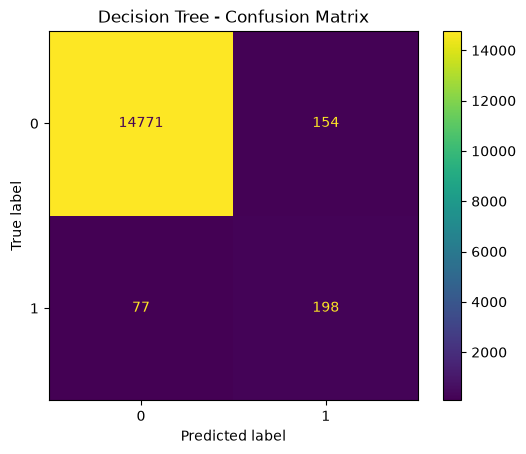

In [61]:
cm = confusion_matrix(y_test, decision_tree_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")

plt.show()

##### ROC Curve

In [62]:
decision_tree_probability = decision_tree_model.predict_proba(x_test)[:, 1]

In [63]:
decision_tree_fpr, decision_tree_tpr, decision_tree_thresholds = roc_curve( y_test,decision_tree_probability)

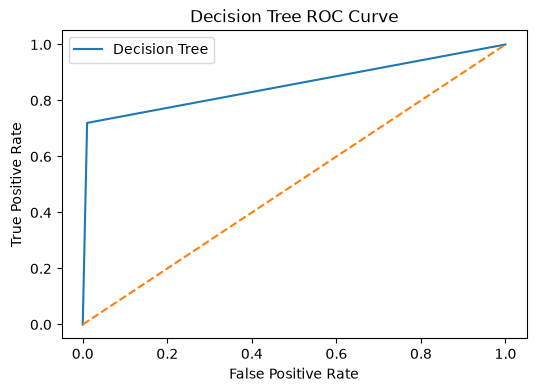

In [64]:
plt.figure(figsize=(6, 4))

plt.plot(
    decision_tree_fpr,
    decision_tree_tpr,
    label="Decision Tree"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [65]:
decision_tree_roc_auc=roc_auc_score(y_test,decision_tree_probability)
print("Decision Tree ROC_AUC:",decision_tree_roc_auc)

Decision Tree ROC_AUC: 0.8548408710217755


## Random Forest Evaluation

In [66]:
random_forest_predictions=random_forest_model.predict(x_test)

##### Accuracy

In [67]:
random_forest_accuracy=accuracy_score(y_test,random_forest_predictions)
print("Random Forest Accuracy:",random_forest_accuracy)

Random Forest Accuracy: 0.9903947368421052


##### Precision

In [68]:
random_forest_precision=precision_score(y_test,random_forest_predictions)
print("Random Forest Precision:",random_forest_precision)

Random Forest Precision: 0.6891495601173021


##### Recall

In [69]:
random_forest_recall=recall_score(y_test,random_forest_predictions)
print("Random Forest Recall:",random_forest_recall)

Random Forest Recall: 0.8545454545454545


##### F1 Score

In [70]:
random_forest_f1=f1_score(y_test,random_forest_predictions)
print("Random Forest F1-Score:",random_forest_f1)

Random Forest F1-Score: 0.762987012987013


##### Classification Report

In [71]:
print(classification_report(y_test,random_forest_predictions))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     14925
           1       0.69      0.85      0.76       275

    accuracy                           0.99     15200
   macro avg       0.84      0.92      0.88     15200
weighted avg       0.99      0.99      0.99     15200



##### Confusion Matrix

In [72]:
random_forest_cm = confusion_matrix(y_test,random_forest_predictions)
print(random_forest_cm)

[[14819   106]
 [   40   235]]


##### Confusion Matrix Display

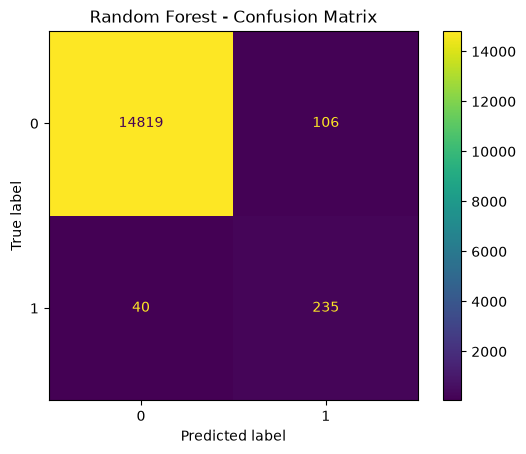

In [73]:
cm = confusion_matrix(y_test, random_forest_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest - Confusion Matrix")

plt.show()

##### ROC

In [74]:
random_forest_probability = random_forest_model.predict_proba(x_test)[:, 1]

In [75]:
random_forest_fpr, random_forest_tpr, random_forest_thresholds = roc_curve( y_test, random_forest_probability)

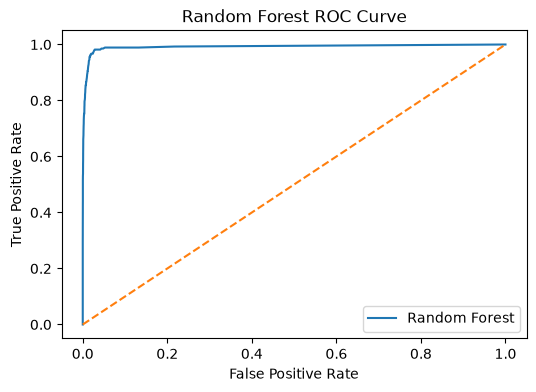

In [76]:
plt.figure(figsize=(6, 4))

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [77]:
random_forest_roc_auc = roc_auc_score(y_test,random_forest_probability)

print("Random Forest ROC-AUC:", random_forest_roc_auc)

Random Forest ROC-AUC: 0.9919806304248515


## SVM Evaluation

In [78]:
svm_predictions = svm_model.predict(x_test)

##### Accuracy

In [79]:
svm_accuracy = accuracy_score( y_test,svm_predictions)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.979078947368421


##### Precision

In [80]:
svm_precision = precision_score( y_test,svm_predictions)

print("SVM Precision:", svm_precision)

SVM Precision: 0.45792563600782776


##### Recall

In [81]:
svm_recall = recall_score(y_test,svm_predictions)

print("SVM Recall:", svm_recall)

SVM Recall: 0.850909090909091


##### F1 Score

In [82]:
svm_f1 = f1_score(y_test,svm_predictions)

print("SVM F1 Score:", svm_f1)

SVM F1 Score: 0.5954198473282443


##### Classification Report

In [83]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14925
           1       0.46      0.85      0.60       275

    accuracy                           0.98     15200
   macro avg       0.73      0.92      0.79     15200
weighted avg       0.99      0.98      0.98     15200



##### Confusion Matrix

In [84]:
svm_cm = confusion_matrix(y_test, svm_predictions)

print(svm_cm)

[[14648   277]
 [   41   234]]


##### Confusion Matrix Display

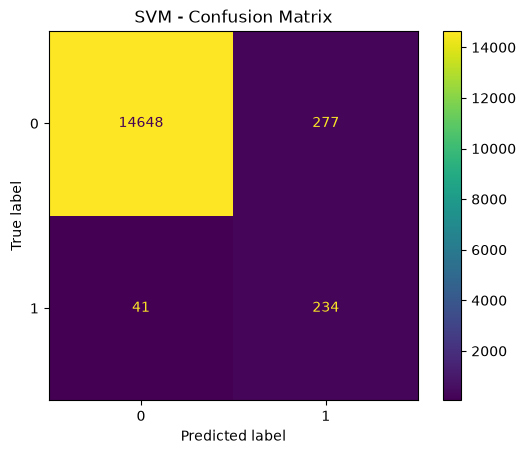

In [85]:
cm = confusion_matrix(y_test, svm_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("SVM - Confusion Matrix")

plt.show()

##### ROC

In [86]:
svm_probability = svm_model.decision_function(x_test)

#it does not have predict_proba().So for your SVM, use decision_function().

In [87]:
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test,svm_probability)

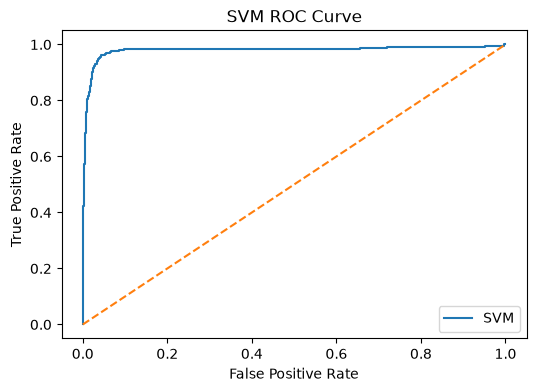

In [88]:
plt.figure(figsize=(6, 4))

plt.plot(
    svm_fpr,
    svm_tpr,
    label="SVM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [89]:
svm_roc_auc = roc_auc_score(y_test,svm_probability)

print("SVM ROC-AUC:", svm_roc_auc)

SVM ROC-AUC: 0.9803132023755139


## Naive Bayes Evaluation

In [90]:
naive_bayes_predictions = naive_bayes_model.predict(x_test)

##### Accuracy

In [91]:
naive_bayes_accuracy = accuracy_score(y_test,naive_bayes_predictions)

print("Naive Bayes Accuracy:", naive_bayes_accuracy)

Naive Bayes Accuracy: 0.962171052631579


##### Precision

In [92]:
naive_bayes_precision = precision_score( y_test,naive_bayes_predictions)

print("Naive Bayes Precision:", naive_bayes_precision)

Naive Bayes Precision: 0.310126582278481


##### Recall

In [93]:
naive_bayes_recall = recall_score( y_test,naive_bayes_predictions)

print("Naive Bayes Recall:", naive_bayes_recall)

Naive Bayes Recall: 0.8909090909090909


##### F1 Score

In [94]:
naive_bayes_f1 = f1_score(y_test,naive_bayes_predictions)

print("Naive Bayes F1 Score:", naive_bayes_f1)

Naive Bayes F1 Score: 0.460093896713615


##### Classification Report

In [95]:
print(classification_report(y_test,naive_bayes_predictions))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     14925
           1       0.31      0.89      0.46       275

    accuracy                           0.96     15200
   macro avg       0.65      0.93      0.72     15200
weighted avg       0.99      0.96      0.97     15200



##### Confusion Matrix

In [96]:
naive_bayes_cm = confusion_matrix(y_test,naive_bayes_predictions)

print(naive_bayes_cm)

[[14380   545]
 [   30   245]]


##### Confusion Matrix Display

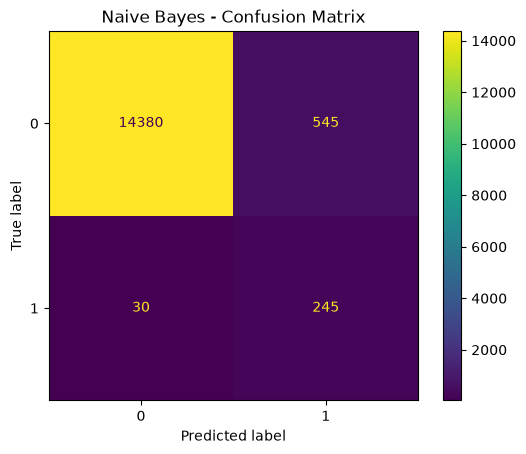

In [97]:
cm = confusion_matrix(y_test, naive_bayes_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Naive Bayes - Confusion Matrix")

plt.show()

##### ROC

In [98]:
naive_bayes_probability = naive_bayes_model.predict_proba(x_test)[:, 1]

In [99]:
naive_bayes_fpr, naive_bayes_tpr, naive_bayes_thresholds = roc_curve(y_test,naive_bayes_probability)

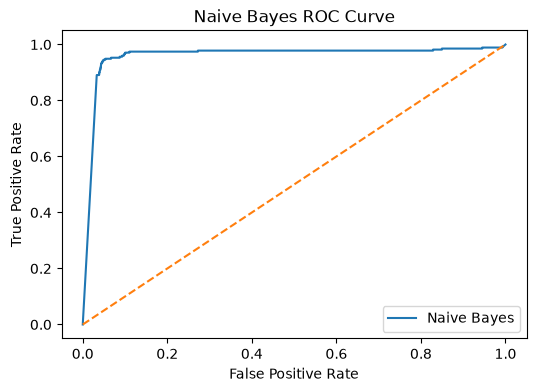

In [100]:
plt.figure(figsize=(6, 4))

plt.plot(
    naive_bayes_fpr,
    naive_bayes_tpr,
    label="Naive Bayes"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Naive Bayes ROC Curve")

plt.legend()

plt.show()

##### ROC_AUC

In [101]:
naive_bayes_roc_auc = roc_auc_score(y_test,naive_bayes_probability)

print("Naive Bayes ROC-AUC:", naive_bayes_roc_auc)

Naive Bayes ROC-AUC: 0.9589662250647176


## Gradient Boosting Evaluation

In [102]:
gradient_boosting_predictions = gradient_boosting_model.predict(x_test)

##### Accuracy

In [103]:
gradient_boosting_accuracy = accuracy_score(y_test,gradient_boosting_predictions)

print("Gradient Boosting Accuracy:", gradient_boosting_accuracy)

Gradient Boosting Accuracy: 0.9775


##### Precision

In [104]:
gradient_boosting_precision = precision_score(y_test,gradient_boosting_predictions)

print("Gradient Boosting Precision:", gradient_boosting_precision)

Gradient Boosting Precision: 0.4404973357015986


##### Recall

In [105]:
gradient_boosting_recall = recall_score(y_test,gradient_boosting_predictions)

print("Gradient Boosting Recall:", gradient_boosting_recall)

Gradient Boosting Recall: 0.9018181818181819


##### F1 Score

In [106]:
gradient_boosting_f1 = f1_score( y_test, gradient_boosting_predictions)

print("Gradient Boosting F1 Score:", gradient_boosting_f1)

Gradient Boosting F1 Score: 0.5918854415274463


##### Classification Report

In [107]:
print(classification_report(y_test,gradient_boosting_predictions))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14925
           1       0.44      0.90      0.59       275

    accuracy                           0.98     15200
   macro avg       0.72      0.94      0.79     15200
weighted avg       0.99      0.98      0.98     15200



##### Confusion Matrix

In [108]:
gradient_boosting_cm = confusion_matrix(y_test,gradient_boosting_predictions)

print(gradient_boosting_cm)

[[14610   315]
 [   27   248]]


##### Confusion Matrix Display

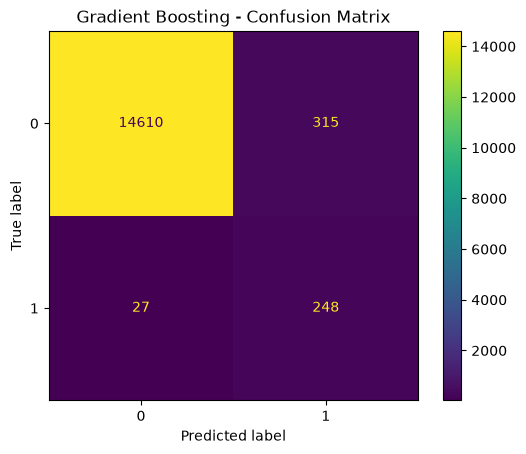

In [109]:
cm = confusion_matrix(y_test, gradient_boosting_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Gradient Boosting - Confusion Matrix")

plt.show()

##### ROC

In [110]:
gradient_boosting_probability = gradient_boosting_model.predict_proba(x_test)[:, 1]

In [111]:
gradient_boosting_fpr, gradient_boosting_tpr, gradient_boosting_thresholds = roc_curve(y_test,gradient_boosting_probability)

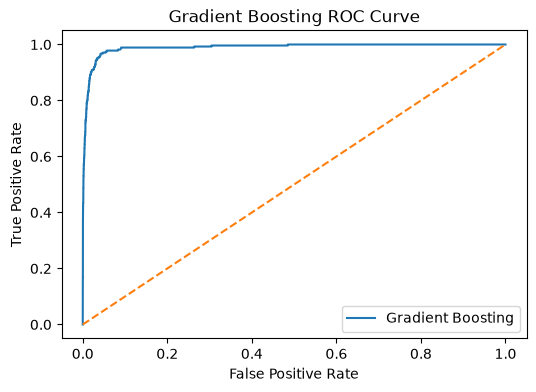

In [112]:
plt.figure(figsize=(6, 4))

plt.plot(
    gradient_boosting_fpr,
    gradient_boosting_tpr,
    label="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Gradient Boosting ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [113]:
gradient_boosting_roc_auc = roc_auc_score(y_test,gradient_boosting_probability)

print("Gradient Boosting ROC-AUC:", gradient_boosting_roc_auc)

Gradient Boosting ROC-AUC: 0.9893715851987208
